In [1]:
%load_ext autoreload
%autoreload 2

import scipy
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
import pandas as pd

from rule_generation_utils import *
from toy_example_utils import *
from geometric_rule_distance import *
from rulesetparsing import *
from utils import *

import time
import os

# **Continuity of the rule similarity function**

In [2]:
method = "GIoU"
res_path = f"test_{method}/"
os.makedirs(res_path, exist_ok=True)

save_plots_flag = False
if save_plots_flag:
    os.makedirs(res_path+"/plots/", exist_ok=True)

test_ID = "rules_X2_fixed"

## 1) Custom Rule Generation Settings

In [3]:
scatter_colors = {0: "b", 1: "r"}
scatter_style = {0: "--", 1: "-"}
n_rules = 30
# X1 variable, X2 fixed 
if test_ID == "rules_X2_fixed":
    l21_range = np.array([0.2]*n_rules)
    u21_range = np.array([0.5]*n_rules)
    l22_range = np.array([0.2]*n_rules)
    u22_range = np.array([0.5]*n_rules)
    l11_range = np.linspace(0, 0.40, n_rules)
    u11_range = np.linspace(0.2, 0.60, n_rules)
    l12_range = np.linspace(0.80, 0.40, n_rules)
    u12_range = np.linspace(1, 0.60, n_rules)
    y1=0
    y2=1
# rules sliding against each other from opposing corners
if test_ID == "rules_2d_sliding":
    l21_range = np.linspace(0.7, 0.35, n_rules)
    u21_range = np.linspace(1.0, 0.65, n_rules)
    l22_range = np.linspace(0, 0.35, n_rules)
    u22_range = np.linspace(0.30, 0.65, n_rules)
    l11_range = np.linspace(0, 0.45, n_rules)
    u11_range = np.linspace(0.1, 0.55, n_rules)
    l12_range = np.linspace(0.90, 0.45, n_rules)
    u12_range = np.linspace(1, 0.55, n_rules)
    y1=0
    y2=1
# keep one rule fixed and slide the other along one of its edges
if test_ID == "1_rule_fixed":
    # fixed rule 1
    l21_range = np.array([0.3]*n_rules)
    u21_range = np.array([0.6]*n_rules)
    l11_range = np.array([0.2]*n_rules)
    u11_range = np.array([0.3]*n_rules)
    # adjacent sliding rule 2
    l22_range = np.linspace(0.6, 0, n_rules)
    u22_range = np.linspace(0.9, 0.3, n_rules)
    l12_range = np.array([0.3]*n_rules)
    u12_range = np.array([0.4]*n_rules)
    y1=0
    y2=1


# 2) Rule similarity assessment

- Rule generation
- Similarity computation, with different options:
    - `method="piecewise"`: piecewise-defined similarity, combining IoU-based term for overlapping/touching rules and a distance-based term for non-overlapping ones
    - `method="GIoU"`: inspired to GIoU metric from object detection
    - `method="distance"`: also in the overlap case, considers the normalized Euclidean distances among nearest borders of two rules
- Save information: rule thresholds and similarity value; compute and memorize rules center positions for a quick continuity check

In [4]:

sim_values = []
c11, c12, c21, c22 = [], [], [], []

with open(res_path+"rulesim_trend.csv", "w") as ff:
    ff.write("l11,u11,l21,u21,l12,u12,l22,u22,similarity\n")
for n, (l11, u11, l12, u12, l21, u21, l22, u22) in enumerate(zip(l11_range, u11_range, l12_range, u12_range, l21_range, u21_range, l22_range, u22_range)):

    print(f"RULE 1: IF {l11} < X1 <= {u11} AND {l21} < X2 <= {u21}")
    print(f"RULE 2: IF {l12} < X1 <= {u12} AND {l22} < X2 <= {u22}")      
    rule_info = [[l11, u11, l21, u21, y1], [l12, u12, l22, u22, y2]]

    ruleset_save_path = res_path+f"synthetic_{test_ID}_{n}.csv"
    rulesim_path = res_path + f"rulesim_{test_ID}_{n}"
    write_and_save_ruleset(rule_info, save_path = ruleset_save_path)


    # Set random seed
    np.random.seed(102)

    # Generate random points for each rule
    R1, w1, h1 = get_rule_points(l11, u11, l21, u21, 1000)
    R2, w2, h2 = get_rule_points(l12, u12, l22, u22, 1000)


    data = np.vstack([np.column_stack([R1, np.zeros((len(R1),1))]), np.column_stack([R2, np.ones((len(R2),1))])])
    dt = pd.DataFrame(data,columns=['X1','X2','output'])
    #outfile = res_path + f"data_{test_ID}_{n}.xlsx"
    #dt.to_excel(outfile, index = False)

    parsedruleset = clean_ruleset_file(ruleset_save_path, dt, ["X1", "X2"], 2, "output")
    parsedruleset.Feature = parsedruleset.Feature.astype("category")
    parsedruleset.Feature = parsedruleset.Feature.cat.set_categories(["X1", "X2"])
    parsedruleset = parsedruleset.sort_values(["Rule ID", "Feature"])
    #print(parsedruleset)

    if method == "GIoU":
        rulesim = GeneralizedIoU(parsedruleset, rulesetfile=ruleset_save_path, SAVE_RS_VALUES=False, save_path=rulesim_path) 
    elif method == "piecewise":
        rulesim = RuleSimilarity(parsedruleset, rulesetfile=ruleset_save_path, SAVE_RS_VALUES=False, save_path=rulesim_path)
    elif method == "distance":
        rulesim = DistanceSimilarity(parsedruleset, rulesetfile=ruleset_save_path, SAVE_RS_VALUES=False, save_path=rulesim_path)

    print(f"Similarity (Rule1, Rule2) - {method} method = ", rulesim[0,1])
    print("\n")
    with open(res_path+"rulesim_trend.csv", "a") as ff:
        ff.write(str(l11)+","+str(u11)+","+str(l21)+","+str(u21)+","+str(l12)+","+str(u12)+","+str(l22)+","+str(u22)+","+str(rulesim[0,1])+"\n")

    # save points for 3d plot
    c11.append((l11+u11)/2)
    c12.append((l12+u12)/2)
    c21.append((l21+u21)/2)
    c22.append((l22+u22)/2)

    sim_values.append(rulesim[0,1])



RULE 1: IF 0.0 < X1 <= 0.2 AND 0.2 < X2 <= 0.5
RULE 2: IF 0.8 < X1 <= 1.0 AND 0.2 < X2 <= 0.5
Similarity (Rule1, Rule2) - GIoU method =  0.2


RULE 1: IF 0.013793103448275864 < X1 <= 0.21379310344827587 AND 0.2 < X2 <= 0.5
RULE 2: IF 0.7862068965517242 < X1 <= 0.9862068965517241 AND 0.2 < X2 <= 0.5
Similarity (Rule1, Rule2) - GIoU method =  0.20567375886524825


RULE 1: IF 0.027586206896551727 < X1 <= 0.22758620689655173 AND 0.2 < X2 <= 0.5
RULE 2: IF 0.7724137931034483 < X1 <= 0.9724137931034482 AND 0.2 < X2 <= 0.5
Similarity (Rule1, Rule2) - GIoU method =  0.21167883211678834


RULE 1: IF 0.04137931034482759 < X1 <= 0.2413793103448276 AND 0.2 < X2 <= 0.5
RULE 2: IF 0.7586206896551725 < X1 <= 0.9586206896551724 AND 0.2 < X2 <= 0.5
Similarity (Rule1, Rule2) - GIoU method =  0.21804511278195488


RULE 1: IF 0.055172413793103454 < X1 <= 0.25517241379310346 AND 0.2 < X2 <= 0.5
RULE 2: IF 0.7448275862068966 < X1 <= 0.9448275862068966 AND 0.2 < X2 <= 0.5
Similarity (Rule1, Rule2) - GIoU met

**3D plot of rule similarity with respect to rule centers**

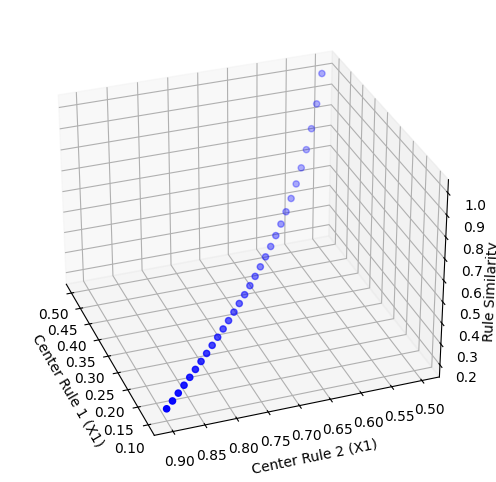

In [5]:
# Convert lists to arrays
C1 = np.array(c11)   # center rule 1
C2 = np.array(c12)   # center rule 2
R  = np.array(sim_values)  # similarity value

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(C1, C2, R, s=20, c='blue')

ax.set_xlabel("Center Rule 1 (X1)")
ax.set_ylabel("Center Rule 2 (X1)")

ax.set_zlabel("Rule Similarity", rotation = 90)
ax.zaxis.labelpad=-0.7
ax.view_init(elev=30, azim=160)

# Extra space around figure (important for 3D)
#plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)
if save_plots_flag:
    plt.savefig(res_path+f"plots/plot_trend_{test_ID}.png", dpi = 200, bbox_inches="tight")
plt.show()

**Show animation of rules and corresponding similarity values**

/var/folders/9h/svsvtj351111fqd57806yp6m0000gn/T/ipykernel_36610/4000114517.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


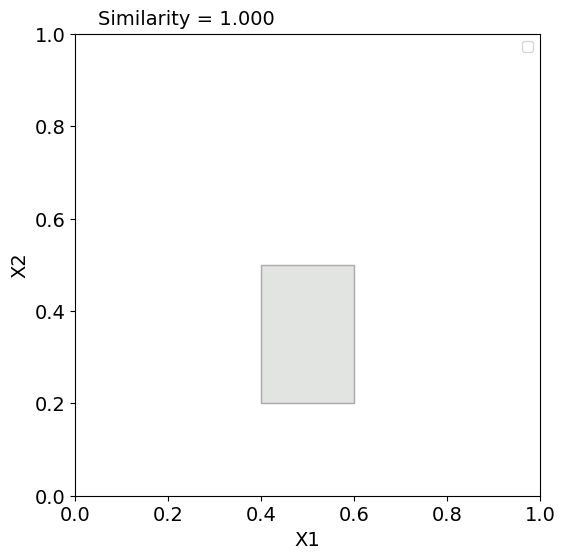

In [6]:
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML

sim_values = []

fig, ax = plt.subplots(figsize=(6,6))

rect1 = plt.Rectangle((0,0), 0, 0, linewidth=1, edgecolor='gray', facecolor='lightskyblue', alpha = 0.4)
rect2 = plt.Rectangle((0,0), 0, 0, linewidth=1, edgecolor='gray', facecolor='peachpuff', alpha = 0.4)
ax.add_patch(rect1)
ax.add_patch(rect2)
text_sim = ax.text(0.05, 1.02, '', transform=ax.transAxes, fontsize=14)

ax.set_xlim([0,1])
ax.set_ylim([0,1])
ax.set_xlabel("X1", fontsize=14)
ax.set_ylabel("X2", fontsize=14)

ax.legend()
ax.tick_params(labelsize=14)

def update(frame):
    n = frame
    l11, u11 = l11_range[n], u11_range[n]
    l12, u12 = l12_range[n], u12_range[n]
    
    l21, u21 = l21_range[n], u21_range[n]
    l22, u22 = l22_range[n], u22_range[n]

    # Generate points
    R1, w1, h1 = get_rule_points(l11, u11, l21, u21, 1000)
    R2, w2, h2 = get_rule_points(l12, u12, l22, u22, 1000)

    # Update rectangles
    rect1.set_xy((l11, l21))
    rect1.set_width(w1)
    rect1.set_height(h1)

    rect2.set_xy((l12, l22))
    rect2.set_width(w2)
    rect2.set_height(h2)



    # compute similarity
    #rule_info = [[l11, u11, l21, u21, y1], [l12, u12, l22, u22, y2]]
    ruleset_save_path = res_path + f"synthetic_{test_ID}_{n}.csv"
    #rulesim_path = res_path + f"rulesim_{test_ID}_{n}"
    #write_and_save_ruleset(rule_info, save_path=ruleset_save_path)

    data = np.vstack([np.column_stack([R1, np.zeros((len(R1),1))]), 
                      np.column_stack([R2, np.ones((len(R2),1))])])
    dt = pd.DataFrame(data, columns=['X1','X2','output'])
    
    parsedruleset = clean_ruleset_file(ruleset_save_path, dt, ["X1", "X2"], 2, "output")
    parsedruleset.Feature = parsedruleset.Feature.astype("category")
    parsedruleset.Feature = parsedruleset.Feature.cat.set_categories(["X1", "X2"])
    parsedruleset = parsedruleset.sort_values(["Rule ID", "Feature"])

    if method == "GIoU":
        rulesim = GeneralizedIoU(parsedruleset, rulesetfile=ruleset_save_path, SAVE_RS_VALUES=False, save_path=rulesim_path) 
    elif method == "piecewise":
        rulesim = RuleSimilarity(parsedruleset, rulesetfile=ruleset_save_path, SAVE_RS_VALUES=False, save_path=rulesim_path)
    elif method == "distance":
        rulesim = DistanceSimilarity(parsedruleset, rulesetfile=ruleset_save_path, SAVE_RS_VALUES=False, save_path=rulesim_path)
    
    
    sim = rulesim[0,1]
    sim_values.append(sim)

    text_sim.set_text(f"Similarity = {sim:.3f}")
    
    return rect1, rect2, text_sim

anim = FuncAnimation(fig, update, frames=len(l11_range), interval=500, blit=True)

# Save as MP4 using FFMpegWriter
writer = FFMpegWriter(fps=2, metadata=dict(artist='Sara'), bitrate=1800)
#anim.save(res_path + f'similarity_{test_ID}.mp4', writer=writer)
HTML(anim.to_html5_video())